# Import everything needed

In [214]:
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter.filedialog import askopenfilenames
from scipy.optimize import curve_fit
import os
import sys
from scipy.interpolate import interp1d
from scipy.io import loadmat
import xarray as xr
#from lmfit import Model, Parameters, minimize
import copy
%matplotlib widget
#Allow more than one notebook output
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"



def load_data(path):
    files =  os.listdir(path)
    if len(files) != 2:
        print("Unexpected number of files. Please, have only the Frog and xFrog in the folder")
        sys.exit()
    data1 = np.loadtxt(os.path.join(path, files[0]))
    data2 = np.loadtxt(os.path.join(path, files[1]))
    if len(data2)>len(data1):
        frog = data2
        xfrog = data1
    else:
        frog = data1
        xfrog = data2
    DataFrame = xr.DataArray(
        np.transpose(frog[1:]),
        coords={"wl": frog[0],"time": xfrog},
        dims =['wl',"time",]
    )
    return DataFrame

def heatmap(DataFrame,Pulse_Length):
    plt.figure()
    plt.pcolormesh(DataFrame['time'],DataFrame['wl'], DataFrame.values, cmap='jet', shading='auto')
    plt.xlabel('time (fs)')
    plt.ylabel('Wavelength  (nm)')
    plt.colorbar()
    plt.text(0.05, 0.95, f'Pulse Length: {Pulse_Length:.1f} fs', 
            fontsize=12, color='white', transform=plt.gca().transAxes,
            ha='left', va='top', bbox=dict(facecolor='black', alpha=0.5))
    plt.show()


def calculate_fwhm(spectral_data, time_coords):
    spectral_data = np.abs(spectral_data)
    peak_value = np.max(spectral_data)
    half_max = peak_value / 2.0
    indices_above_half = np.where(spectral_data >= half_max)[0]
    # Interpolate to get a more accurate crossing point
    f_left = interp1d(spectral_data[indices_above_half[0]-1:indices_above_half[0]+1], time_coords[indices_above_half[0]-1:indices_above_half[0]+1], kind='linear')
    f_right = interp1d(spectral_data[indices_above_half[-1]:indices_above_half[-1]+2], time_coords[indices_above_half[-1]:indices_above_half[-1]+2], kind='linear')
    left_half_max_time = f_left(half_max)
    right_half_max_time = f_right(half_max)
    
    # Calculate FWHM as the difference between these two time points
    fwhm = right_half_max_time - left_half_max_time

    return fwhm

def gaussian(x, mu, sigma):
  return np.exp(-np.power(x - mu, 2.) / (2 * np.power(sigma, 2.)))

###Speed of light conversion ################
c = 299792458 #m/s
c = c*1000 #mm/s
c = c*10**(-15) #mm/fs


# Input 

In [249]:
file_path = r'/Users/vard/Documents/FROG_Matlab/241206_800_400nm/241207/Final/NewBBO_Stage_position0' #Should include only xFrog and Frog 
WLLims = [240,300] #Region where you see the FROG signal
autocorrelation = False 

if autocorrelation == False:
    gate_time = 35 #in fs

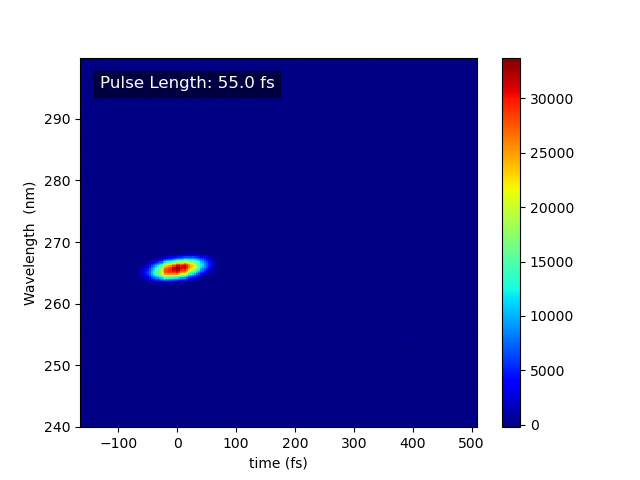

Text(0.5, 1.0, 'Frog 400nm-800nm')

<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'time (fs)')

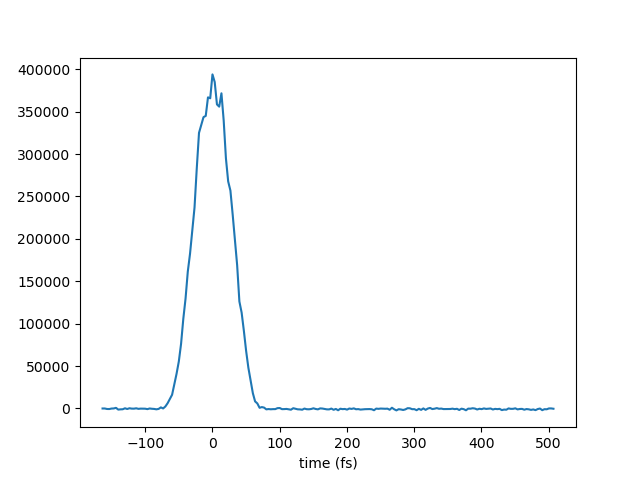

In [251]:
Data = load_data(file_path)
Data = Data.sel(wl= slice(WLLims[0],WLLims[1]))
x0 = Data['time'][Data.sum(dim='wl').argmax()].values #Position of where the Frog is centered
Data['time'] = ((Data['time'].values - x0)/c)*2 #Multiply by 2 as moving the stage changes the distance two time (in and out)
if autocorrelation == True:
    Pulse_length = calculate_fwhm(Data.sum(dim='wl').values, Data['time'])/np.sqrt(2)
else:
    Pulse_length = np.sqrt(calculate_fwhm(Data.sum(dim='wl').values, Data['time'])**2-gate_time**2)
heatmap(Data,Pulse_length)
plt.title("Frog 400nm-800nm")
plt.figure()
Data.sum(dim='wl').plot()
plt.xlabel('time (fs)')
plt.show()


In [235]:
calculate_fwhm(Data.sum(dim='wl').values, Data['time'])

33.51293125580267